# 异常值检验

In [13]:
import os
import numpy as np
import pandas as pd

## 加载原始数据

In [14]:
df = pd.read_csv('../data/raw/sales_data.csv')
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


## 筛选连续数值变量

In [15]:
# 识别二元列
binary_cols = [col for col in df.columns if df[col].nunique() <= 2]
# 获取初始列
numeric_cols = df.select_dtypes(include='number').columns
# 过滤二元列
cols =  [col for col in numeric_cols if col not in binary_cols]

In [16]:
# 方法二，使用差集函数
# cols = np.setdiff1d(numeric_cols, binary_cols)

In [17]:
cols

['Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Price',
 'Discount',
 'Competitor Pricing',
 'Demand']

In [18]:
numeric_data = df[cols]
numeric_data.head()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing,Demand
0,195,102,252,72.72,5,85.73,115
1,117,117,249,80.16,15,92.02,229
2,247,114,612,62.94,10,60.08,157
3,139,45,102,87.63,10,85.19,52
4,152,65,271,54.41,0,51.63,59


## 保存过滤后的数据

In [19]:
file_path = "../data/processed/numeric_data.csv"

numeric_data.to_csv(file_path, index=False)

if os.path.exists(file_path):
    print(f"File saved successfully!\nFile location: {os.path.abspath(file_path)}")
else:
    print("Save failed. Please check the path or permissions.")

File saved successfully!
File location: F:\ZeroPrograming\JupyterNotebook\Retail_Demand_Forecast\data\processed\numeric_data.csv


## IQR法
- 异常值定义：
  如果 $x<(Q_1-1.5\times IQR)$ 或 $x>(Q_3+1.5\times IQR)$，那么x为异常值

In [20]:
# 计算每列的异常值上下界
Q1 = numeric_data[cols].quantile(0.25)
Q3 = numeric_data[cols].quantile(0.75)
IQR = Q3 - Q1

# 计算异常值的上下界
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 查找所有列的异常值，产生布尔索引
outliers = (numeric_data[cols] < lower_bound) | (numeric_data[cols] > upper_bound)

# 统计每列异常值的数量和占比
outlier_count = outliers.sum()
outlier_ratio = outlier_count / len(numeric_data) * 100

# 创建一个包含异常值数量和占比的 DataFrame
outlier_stats = pd.DataFrame({
    'Outlier Count': outlier_count,
    'Outlier Ratio (%)': outlier_ratio
})

# 输出异常值统计结果
print(outlier_stats)

# 将所有含有异常值的记录提取出来（根据每一列的布尔索引）
outlier_data = df[outliers.any(axis=1)]

# 显示所有含有异常值的记录
print(outlier_data)

                    Outlier Count  Outlier Ratio (%)
Inventory Level              2759           3.630263
Units Sold                   1411           1.856579
Units Ordered                7524           9.900000
Price                          70           0.092105
Discount                    12413          16.332895
Competitor Pricing            185           0.243421
Demand                        986           1.297368
             Date Store ID Product ID     Category Region  Inventory Level  \
1      2022-01-01     S001      P0002     Clothing  North              117   
2      2022-01-01     S001      P0003     Clothing  North              247   
6      2022-01-01     S001      P0007    Groceries  North              118   
13     2022-01-01     S001      P0014    Groceries  North              252   
15     2022-01-01     S001      P0016    Groceries  North              103   
...           ...      ...        ...          ...    ...              ...   
75934  2024-01-30     S002    

## 异常值统计结果保存为csv文件

In [23]:
outlier_stats.to_csv('../data/processed/outlier_stats.csv')

## 异常值记录保存为csv文件

In [8]:
outlier_data.to_csv('../data/processed/outlier_data.csv')

## 异常值分布可视化

In [8]:
import pandas as pd

numeric_data = pd.read_csv('../data/processed/numeric_data.csv')

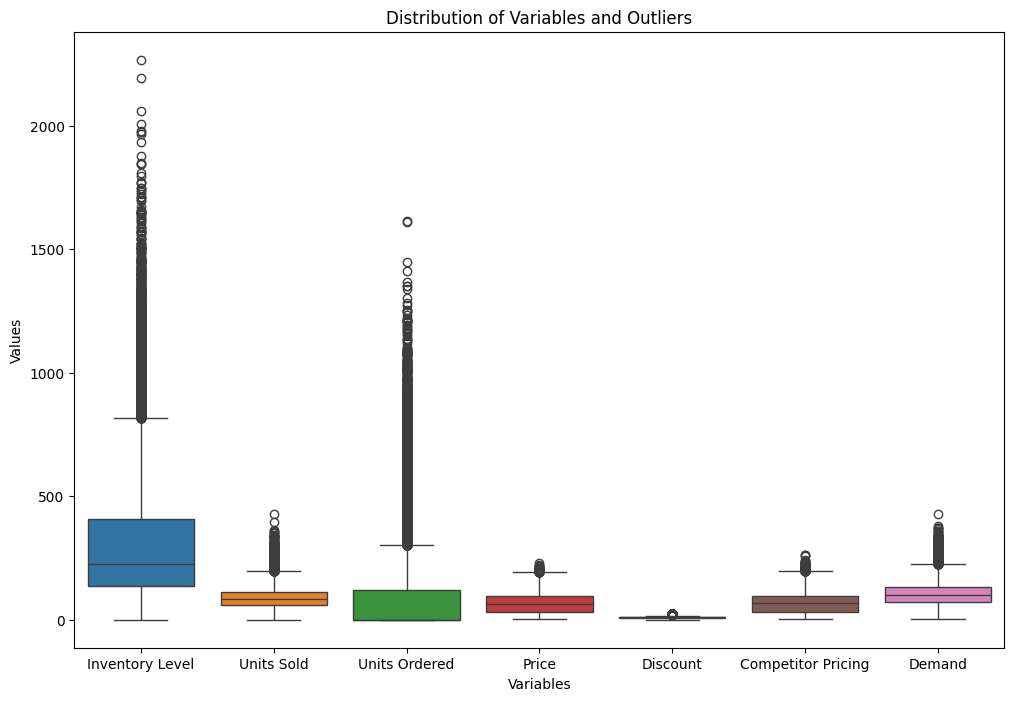

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 选择需要检查的列
cols = ['Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Competitor Pricing', 'Demand']

# 绘制箱线图
plt.figure(figsize=(12, 8))
sns.boxplot(data=numeric_data[cols])
plt.title('Distribution of Variables and Outliers')
plt.xlabel('Variables')
plt.ylabel('Values')
plt.show()

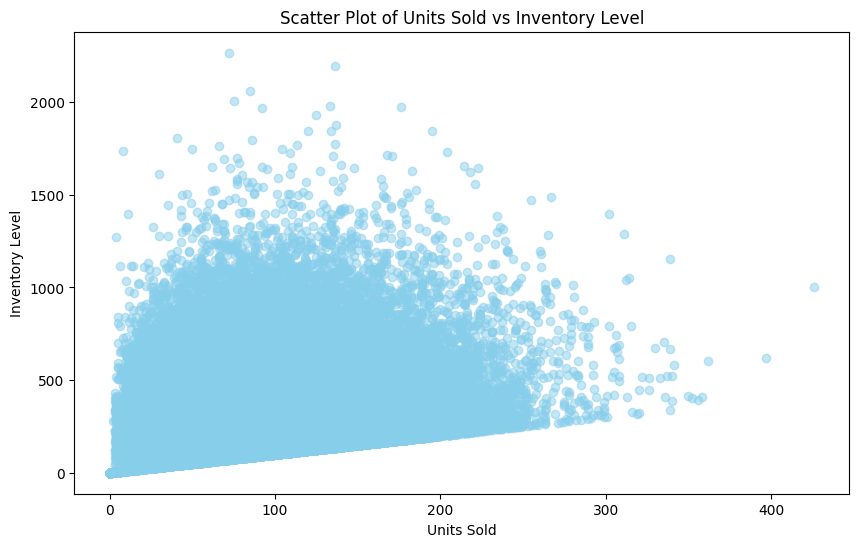

In [10]:
plt.figure(figsize=(10, 6))

# 绘制散点图，查看销量和库存之间的关系
plt.scatter(numeric_data['Units Sold'], numeric_data['Inventory Level'], alpha=0.5, color='skyblue')
plt.title('Scatter Plot of Units Sold vs Inventory Level')
plt.xlabel('Units Sold')
plt.ylabel('Inventory Level')
plt.show()

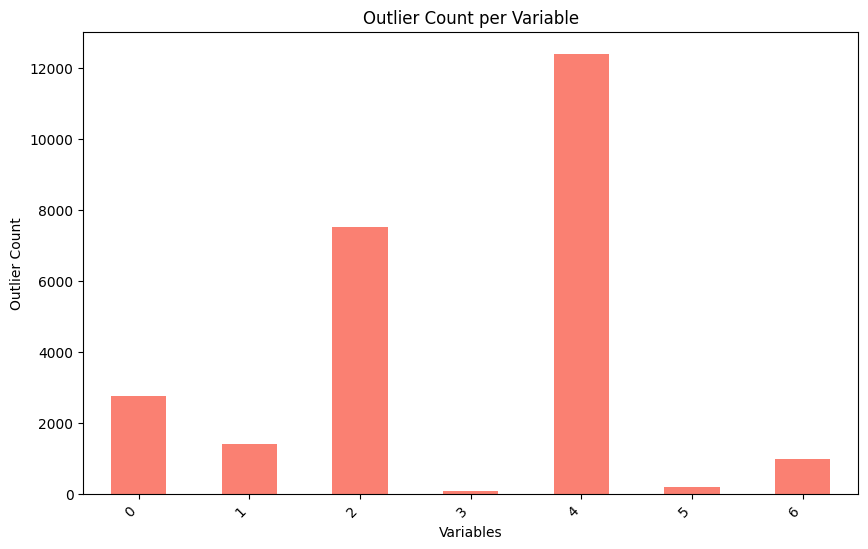

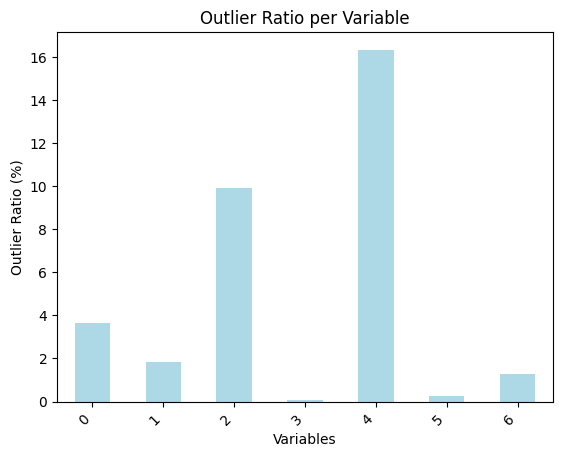

In [12]:
# 将异常值的数量和占比可视化
outlier_stats_df = pd.read_csv('../data/processed/outlier_stats.csv')

plt.figure(figsize=(10, 6))

# 绘制异常值数量的柱状图
outlier_stats_df['Outlier Count'].plot(kind='bar', color='salmon')
plt.title('Outlier Count per Variable')
plt.xlabel('Variables')
plt.ylabel('Outlier Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# 绘制异常值比例的柱状图
outlier_stats_df['Outlier Ratio (%)'].plot(kind='bar', color='lightblue')
plt.title('Outlier Ratio per Variable')
plt.xlabel('Variables')
plt.ylabel('Outlier Ratio (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

# TEST: 项目文件结构与日志生成

In [13]:
import os

current_dir = os.getcwd()              # 当前工作目录 (例如 .../Retail_Demand_Forecast/notebooks)
project_root = os.path.dirname(current_dir)  # 上一级目录，即 Retail_Demand_Forecast

print("📂 当前项目根目录:", project_root)

def print_tree(startpath, level=0):
    items = sorted(os.listdir(startpath))
    for i, item in enumerate(items):
        path = os.path.join(startpath, item)
        connector = "└── " if i == len(items) - 1 else "├── "
        icon = "📁 " if os.path.isdir(path) else "📄 "
        print("│   " * level + connector + icon + item)
        if os.path.isdir(path):
            print_tree(path, level + 1)

print_tree(project_root)

📂 当前项目根目录: F:\ZeroPrograming\JupyterNotebook\Retail_Demand_Forecast
├── 📁 .git
│   ├── 📁 .idea
│   │   ├── 📄 .git.iml
│   │   ├── 📁 inspectionProfiles
│   │   │   ├── 📄 Project_Default.xml
│   │   │   └── 📄 profiles_settings.xml
│   │   ├── 📄 misc.xml
│   │   ├── 📄 modules.xml
│   │   └── 📄 workspace.xml
│   ├── 📄 COMMIT_EDITMSG
│   ├── 📄 FETCH_HEAD
│   ├── 📄 HEAD
│   ├── 📄 ORIG_HEAD
│   ├── 📄 config
│   ├── 📄 description
│   ├── 📁 hooks
│   │   ├── 📄 applypatch-msg.sample
│   │   ├── 📄 commit-msg.sample
│   │   ├── 📄 fsmonitor-watchman.sample
│   │   ├── 📄 post-update.sample
│   │   ├── 📄 pre-applypatch.sample
│   │   ├── 📄 pre-commit.sample
│   │   ├── 📄 pre-merge-commit.sample
│   │   ├── 📄 pre-push.sample
│   │   ├── 📄 pre-rebase.sample
│   │   ├── 📄 pre-receive.sample
│   │   ├── 📄 prepare-commit-msg.sample
│   │   ├── 📄 push-to-checkout.sample
│   │   ├── 📄 sendemail-validate.sample
│   │   └── 📄 update.sample
│   ├── 📄 index
│   ├── 📁 info
│   │   └── 📄 exclude
│   ├── 📁 logs
│ 

In [10]:
import os
import sys
import pandas as pd
import numpy as np

# === 导入模块 ===
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "src")))
from utils.log_utils import Logger

logger = Logger(log_prefix="outlier_detection")

try:
    logger.start_timer()
    logger.log("🚀 异常值检测任务开始")

    base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
    data_path = os.path.join(base_dir, "data", "raw", "sales_data.csv")

    df = pd.read_csv(data_path)
    logger.log(f"数据加载完成: {data_path}, 样本数={len(df)}, 字段数={df.shape[1]}")

    # 异常值检测
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    mild, extreme = 0, 0
    for col in numeric_cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        mild_mask = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
        extreme_mask = (df[col] < q1 - 3 * iqr) | (df[col] > q3 + 3 * iqr)
        mild += mild_mask.sum()
        extreme += extreme_mask.sum()

    logger.log(f"检测完成：mild={mild}, extreme={extreme}")

    logger.end_timer(task_name="outlier_detection")

except Exception as e:
    logger.exception(e, task_name="outlier_detection")

[2025-10-17 09:22:53] 🚀 日志系统初始化成功
[2025-10-17 09:22:53] ⏱️ 任务计时开始
[2025-10-17 09:22:53] 🚀 异常值检测任务开始
[2025-10-17 09:22:53] 数据加载完成: F:\ZeroPrograming\JupyterNotebook\Retail_Demand_Forecast\data\raw\sales_data.csv, 样本数=76000, 字段数=16
[2025-10-17 09:22:54] 检测完成：mild=40548, extreme=19001
[2025-10-17 09:22:55] ⏱️ 总耗时: 0.35 秒
[2025-10-17 09:22:55] 💻 CPU使用率: 36.0%
[2025-10-17 09:22:55] 🧠 内存占用: 134.59 MB
